# 🚢 Titanic Survival Predictor

## Project Overview

This project uses machine learning to predict whether a passenger aboard the Titanic survived based on information about the passenger.

A logistic regression model is trained using passenger class, sex, age, family information, and ticket fare.

The model achieved approximately **81% accuracy** on the test dataset.

### Key Results

- Model: Logistic Regression
- Test Accuracy: **81.0%**
- Baseline Accuracy: **61.6%**
- Survivor Precision: **80%**
- Survivor Recall: **72%**
- Survivor F1-Score: **76%**

The project also includes exploratory data analysis, model evaluation, visualizations, and a discussion of limitations.

In [ ]:
print("Hello! I'm learning machine learning.")

Hello! I'm learning machine learning.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.shape

(891, 12)

In [ ]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
df["Survived"].value_counts()

,count
Survived,
0,549
1,342


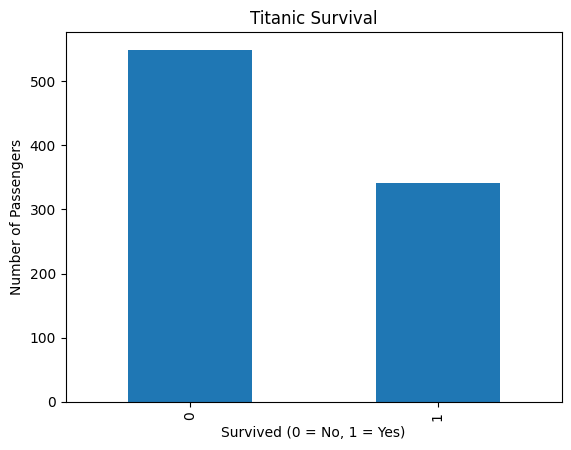

In [ ]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")

plt.title("Titanic Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [ ]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


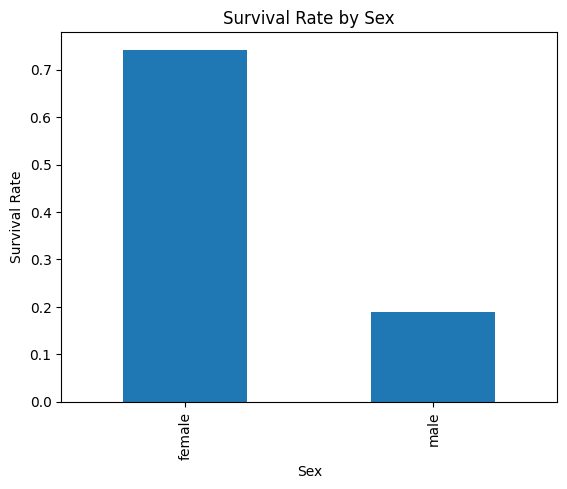

In [ ]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()

survival_by_sex.plot(kind="bar")

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


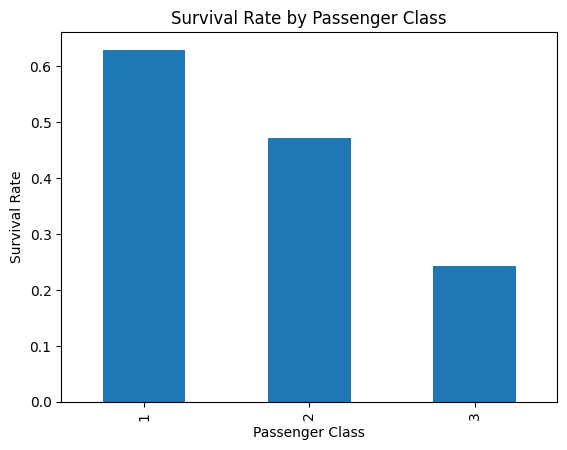

In [ ]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(kind="bar")

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]

X = df[features]
y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

sex_encoded = encoder.fit_transform(X[["Sex"]])

sex_encoded[:5]

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [ ]:
df["Age"].median()

28.0

In [ ]:
X["Age"] = X["Age"].fillna(28)

X.isnull().sum()

/tmp/ipykernel_700/2893553456.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(28)


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training passengers:", len(X_train))
print("Testing passengers:", len(X_test))

Training passengers: 712
Testing passengers: 179


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_features = ["Sex"]
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  SimpleImputer(strategy='median'),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = model.predict(X_test)

y_pred[:20]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92 13]
 [21 53]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



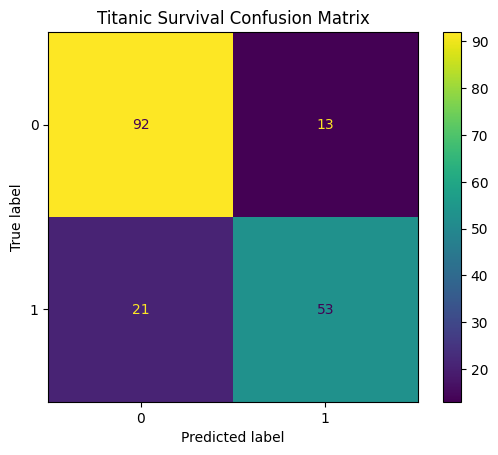

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Titanic Survival Confusion Matrix")
plt.show()

In [ ]:
baseline_accuracy = y.value_counts(normalize=True).max()

print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.6161616161616161


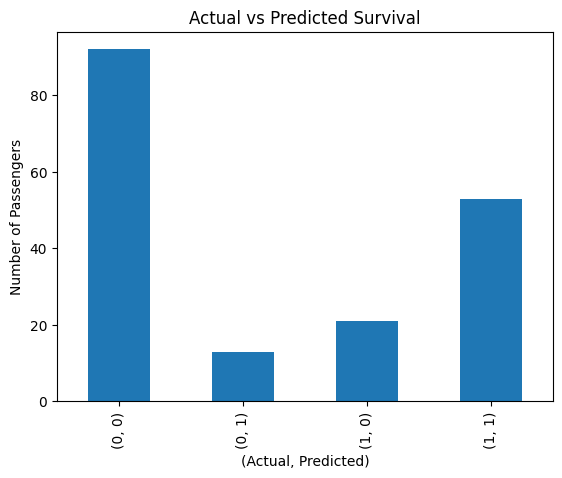

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.value_counts().sort_index().plot(kind="bar")

plt.title("Actual vs Predicted Survival")
plt.xlabel("(Actual, Predicted)")
plt.ylabel("Number of Passengers")

plt.show()

## Methodology

This project uses logistic regression to predict whether a Titanic passenger survived.

### Features
The model uses:
- Passenger class (`Pclass`)
- Sex
- Age
- Number of siblings/spouses aboard (`SibSp`)
- Number of parents/children aboard (`Parch`)
- Ticket fare (`Fare`)

### Data Preparation
Missing age values were handled using median imputation. Categorical values such as sex were converted into numerical values using one-hot encoding.

### Model
A logistic regression model was trained using 80% of the dataset and evaluated on the remaining 20%.

### Evaluation
Model performance was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

## Limitations

This project has several limitations:

- The Titanic dataset is relatively small and historical.
- The model only uses a limited set of passenger features.
- Missing values may affect model performance.
- Logistic regression assumes a relatively simple relationship between the features and survival probability.
- An accuracy of 81% does not mean the model is correct for every passenger.
- Results may change with a different train/test split or model.